## MALL CUSTOMERS DATASET ANALYSIS

## PROBLEM STATEMENT AND OBJECTIVE

## Problem Statement
Businesses often serve customers with varying purchasing behaviors, income levels, and demographic characteristics. Applying the same marketing strategy to all customers may result in inefficient resource allocation and lower customer engagement.

Customer segmentation using clustering techniques can help identify groups of customers with similar characteristics, allowing businesses to develop targeted marketing campaigns and improve customer satisfaction.

## Objective
The objectives of this project are to:
* Explore customer demographic and spending behavior.
* Perform customer segmentation using K-Means Clustering.
* Visualize customer clusters using PCA.
* Interpret the characteristics of each customer segment.
* Recommend marketing strategies tailored to each segment.

## DATASET DESCRIPTION 

## Dataset Name 
Mall Customers Dataset 

## Dataset Overview 
The Mall Customers dataset contains demographic information and spending patterns of customers visiting a shopping mall. The dataset is commonly used for customer segmentation and clustering analysis.

The primary goal is to group customers based on similarities in age, income, and spending behavior.

## Features Description 
| Feature                | Description                           |
| ---------------------- | ------------------------------------- |
| CustomerID             | Unique customer identifier            |
| Genre                  | Gender of customer                    |
| Age                    | Customer age                          |
| Annual Income (k$)     | Annual income in thousands of dollars |
| Spending Score (1-100) | Mall-assigned spending score          |

## DATASET LOADING

In [1]:
# Import libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install openpyxl

In [3]:
# Load dataset
mall = pd.read_excel("Mall_Customers.xlsx")

In [4]:
# Display dataset shape 
mall.shape

(200, 5)

In [5]:
# View first 5 rows 
mall.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# View last 5 rows 
mall.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [7]:
# Check data types 
mall.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [8]:
# Summary statistics
mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## DATA CLEANING AND PREPROCESSING 

In [9]:
# Check missing values 
mall.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
# Handle missing values 
for col in mall.select_dtypes(include=np.number):
    mall[col] = mall[col].fillna(mall[col].median())

In [11]:
# Check dupilcates 
mall.duplicated().sum()

np.int64(0)

In [12]:
# Encode gender 
mall["Genre"] = mall["Genre"].map({"Male":0,
                                   "Female":1})

## EXPLORATORY DATA ANALYSIS (EDA)

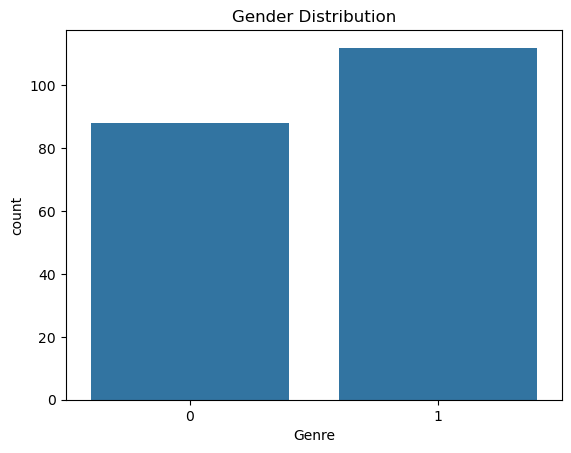

In [13]:
# Gender Distribution 
sns.countplot(x='Genre',
              data=mall)

plt.title("Gender Distribution")

plt.show()

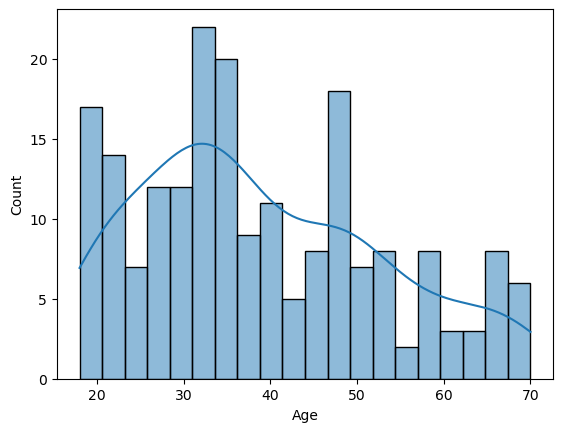

In [14]:
## Age Distribution
sns.histplot(mall['Age'],
             bins=20,
             kde=True)

plt.show()

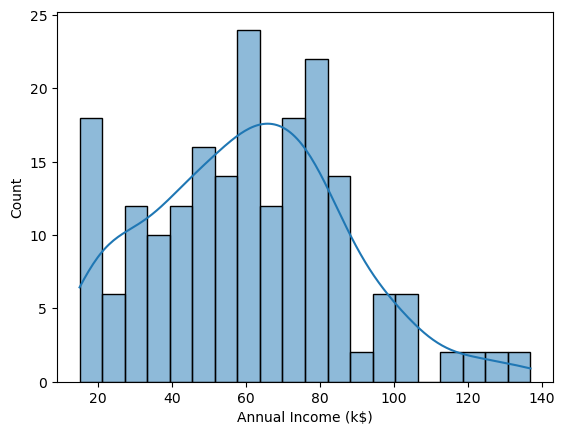

In [15]:
# Annual Income Distribution 
sns.histplot(mall['Annual Income (k$)'],
             bins=20,
             kde=True)

plt.show()

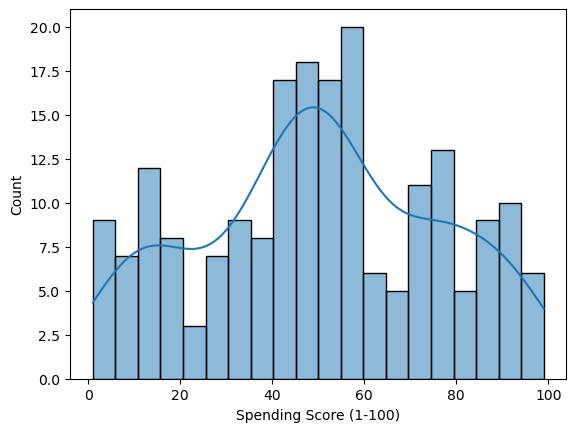

In [16]:
# Spending Score Distribution 
sns.histplot(mall['Spending Score (1-100)'],
             bins=20,
             kde=True)

plt.show()

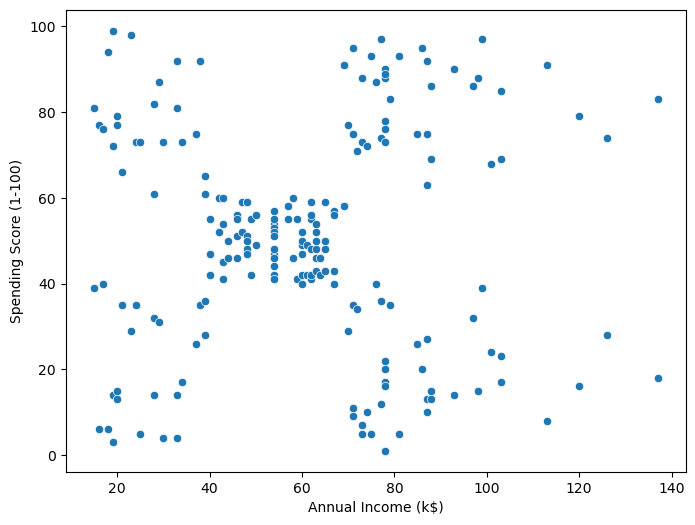

In [17]:
# Income vs Spending Score 
plt.figure(figsize=(8,6))

sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=mall)

plt.show()

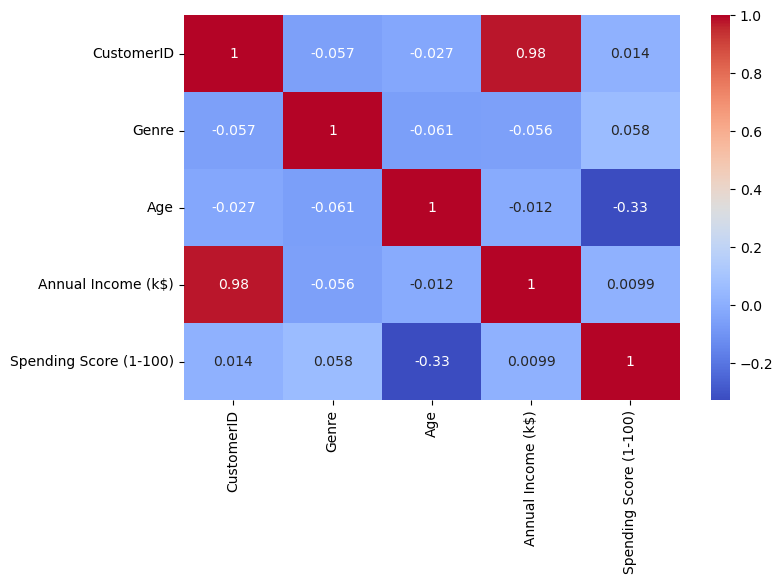

In [18]:
# Correlation Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(mall.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

## FEATURE ENGINEERING AND SCALING

In [19]:
# Select Clustering Features 
X = mall[['Age',
          'Annual Income (k$)',
          'Spending Score (1-100)']]

In [20]:
# Scale Features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## K-MEANS CLUSTERING

In [21]:
# Determine Optimal Clusters (Elbow Method)
inertia = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k,
                    random_state=42)

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

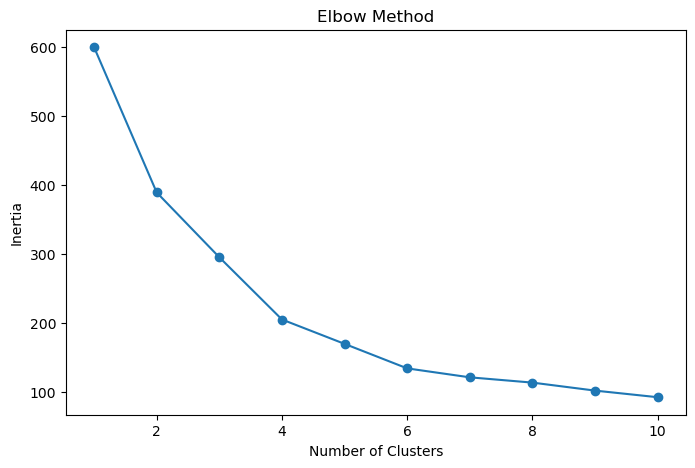

In [22]:
# Elbow Plot
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         inertia,
         marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [23]:
# Build Final KMeans Model 
kmeans = KMeans(n_clusters=5,
                random_state=42)

mall['Cluster'] = kmeans.fit_predict(X_scaled)

In [24]:
# Cluster Distribution 
mall['Cluster'].value_counts()

Cluster
0    58
3    45
1    40
4    31
2    26
Name: count, dtype: int64

## PCA CLUSTER VISUALIZATION

In [25]:
# Apply PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

In [26]:
# PCA DataFrame
pca_df = pd.DataFrame({'PC1':pca_components[:,0],
                       'PC2':pca_components[:,1],
                       'Cluster':mall['Cluster']})

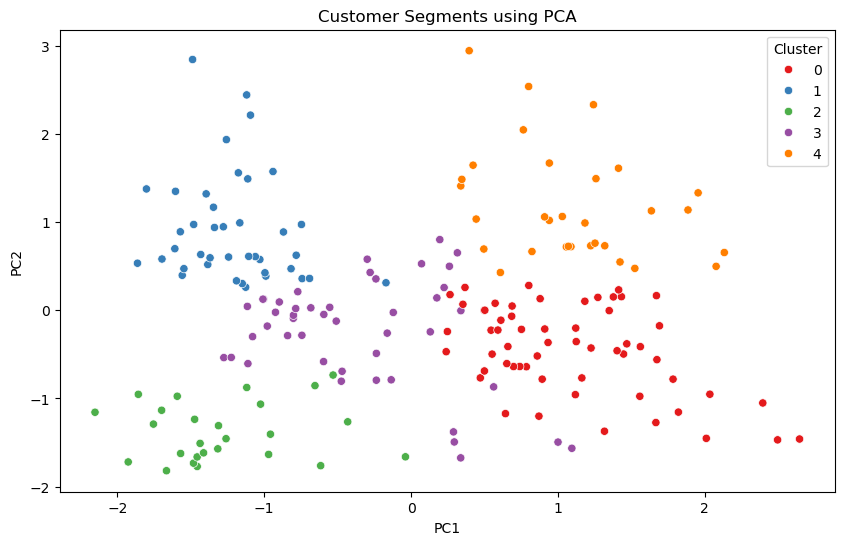

In [27]:
# Visualize Clusters
plt.figure(figsize=(10,6))

sns.scatterplot(x='PC1',
                y='PC2',
                hue='Cluster',
                data=pca_df,
                palette='Set1')

plt.title("Customer Segments using PCA")

plt.show()

In [28]:
# Cluster Interpretation
cluster_profile = mall.groupby('Cluster')[['Age',
                                           'Annual Income (k$)',
                                           'Spending Score (1-100)']].mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


## MARKETING STRATEGIES 

## Cluster 0: 
## Characteristics
* Younger customers
* Moderate income
* High spending behavior

## Strategy
* Loyalty rewards
* Early access to new products
* Personalized recommendations
* Mobile app promotions

## Cluster 1: 
## Characteristics
* High income
* High spending score

## Strategy
* VIP membership programs
* Premium product offerings
* Exclusive events
* Personalized concierge services

## Cluster 2:
## Characteristics
* Lower income
* Lower spending score

## Strategy
* Discount campaigns
* Bundle offers
* Price-sensitive promotions
* Seasonal sales incentives

## Cluster 3:
## Characteristics
* Older customers
* Moderate spending patterns

## Strategy
* Relationship marketing
* Personalized communication
* Customer retention initiatives
* Convenience-focused services

## Cluster 4: 
## Characteristics
* High income
* Low spending score

## Strategy
* Upselling and cross-selling
* Personalized promotions
* Targeted advertising
* Premium trial offers

## BUSINESS INSIGHTS AND RECOMMENDATIONS 

## Key Insights
## 1. Customer Segmentation Results
The Elbow Method suggested that five customer segments provide a suitable clustering solution.

The PCA visualization shows clear separation between clusters, indicating meaningful customer groupings based on age, income, and spending behavior.

## 2. Cluster Characteristics
Based on the cluster profile table and PCA visualization:
* Customers differ significantly in spending behavior and income levels.
* High-income customers do not always exhibit high spending behavior.
* Some customers demonstrate high spending despite moderate income levels.
* Several customer groups require different marketing approaches to maximize engagement and profitability.

## Recommendations 
1. Develop customized campaigns for each cluster.
2. Focus retention efforts on high-spending customers.
3. Increase engagement among high-income, low-spending customers.
4. Utilize loyalty programs to strengthen customer relationships.
5. Continuously update segmentation models as customer behavior evolves.

## CONCLUSION 
This project successfully segmented mall customers into five distinct groups using K-Means Clustering. PCA visualization confirmed clear separation among the identified clusters.

The segmentation process revealed meaningful differences in customer spending patterns, income levels, and demographic characteristics. These insights can support targeted marketing campaigns, improve customer engagement, and increase overall business profitability.

Customer segmentation provides valuable strategic information that enables businesses to deliver personalized experiences and optimize resource allocation.